# fastai : Du modèle à la production
Basé sur le chapitre 2 du livre *Deep Learning for Coders*. Nous allons réaliser un classificateur d'ours (`grizzly` / `ours noir` / `ours en peluche`) de bout en bout : de la collecte des données à l'entraînement, au nettoyage, à l'exportation, au service, à la sécurisation et au déploiement du modèle.

**Philosophie Drivetrain (Moteur de décision) :**
* **Objectif :** Classifier de manière fiable une photo d'ours.
* **Levier d'action :** Accepter la prédiction, la rejeter ou demander l'avis d'un opérateur humain en cas de doute.
* **Données :** Images collectées sur le Web combinées aux retours d'expérience issus de la production.

In [1]:
# Installation des bibliothèques nécessaires
# - fastai : framework de deep learning basé sur PyTorch
# - duckduckgo_search | serpapi : pour récupérer des images de démonstration
# - fastapi, uvicorn, python-multipart : pour créer et servir l'API de production
# - gradio : pour générer une interface de démonstration interactive
# - ipywidgets : requis par fastai pour l'outil de nettoyage et d'affichage interactif
!pip install -q -U fastai duckduckgo_search fastapi uvicorn python-multipart gradio ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.9/242.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.4/144.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.9/152.9 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 89.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sou

In [2]:
from fastai.vision.all import *
from fastai.vision.widgets import ImageClassifierCleaner
from duckduckgo_search import DDGS
import json, time, shutil

## 1. Collecte des données
Le livre original utilise l'API de recherche d'images de Google Search. Comme les services et les clés d'accès changent régulièrement, nous utilisons ici l'API de SerAPI via la bibliothèque `serpapi`. Vous pouvez facilement adapter ce code pour utiliser une autre source ou importer vos propres images locales.

In [3]:
import os, requests, shutil
from pathlib import Path
from fastai.vision.all import L, get_image_files, verify_images, download_images

try:
    from google.colab import userdata
    SERPAPI_KEY = userdata.get("SERPER_API_KEY")
except Exception:
    SERPAPI_KEY = os.environ.get("SERPER_API_KEY")

def search_images(term, max_images=30):
    urls, page = [], 0
    if not SERPAPI_KEY:
        print("[Warning] No SERPER_API_KEY found. Please add it to your Colab secrets.")
        return L()
    try:
        while len(urls) < max_images:
            r = requests.get(
                "https://serpapi.com/search",
                params={
                    "engine": "google_images",
                    "q": term,
                    "ijn": page,          # pagination : 100 images par page
                    "api_key": SERPAPI_KEY,
                },
                timeout=30,
            )
            if r.status_code == 401:
                print(f"[SerpApi] 401 Unauthorized: Please check your SERPER_API_KEY.")
                break
            r.raise_for_status()
            results = r.json().get("images_results", [])
            if not results:
                break
            urls += [x["original"] for x in results if x.get("original")]
            page += 1
        return L(urls[:max_images])
    except Exception as e:
        print(f"[SerpApi] error searching for {term}: {e}")
        return L()

# Définition des classes d'ours que nous souhaitons classifier
bear_types = 'grizzly', 'black', 'teddy'

# Définition globale du chemin
path = Path('/content/bears')
path.mkdir(exist_ok=True, parents=True)

# Téléchargement des images via SerpApi
for o in bear_types:
    dest = path/o
    dest.mkdir(exist_ok=True, parents=True)
    print(f"Recherche et téléchargement via SerpApi pour : {o} bear...")
    urls = search_images(f'{o} bear', max_images=30)
    if len(urls) > 0:
        try:
            download_images(dest, urls=urls)
        except Exception as e:
            print(f"Erreur lors du téléchargement pour {o} : {e}")

# Récupération de tous les fichiers téléchargés et suppression des fichiers corrompus
fns = get_image_files(path)
failed = verify_images(fns)
failed.map(Path.unlink)

print(f"\nSuccès : {len(get_image_files(path))} images de démonstration sont prêtes dans {path} pour l'entraînement !")

Recherche et téléchargement via SerpApi pour : grizzly bear...
Recherche et téléchargement via SerpApi pour : black bear...
Recherche et téléchargement via SerpApi pour : teddy bear...

Succès : 74 images de démonstration sont prêtes dans /content/bears pour l'entraînement !


## 2. Définition du DataBlock et des DataLoaders
Nous configurons ici le pipeline de traitement des données de `fastai` :
* **Blocks :** Entrée sous forme d'image (`ImageBlock`) et sortie sous forme de catégorie de classification (`CategoryBlock`).
* **get_items :** Fonction pour récupérer récursivement les fichiers d'images.
* **splitter :** Division aléatoire avec 20 % des données réservées pour la validation et un grain aléatoire (`seed`) fixé à 42 pour garantir la reproductibilité.
* **get_y :** La classe (étiquette) est déduite du nom du dossier parent.
* **item_tfms :** Redimensionnement et rognage aléatoire (`RandomResizedCrop`) à 224 pixels pour harmoniser la taille des images.
* **batch_tfms :** Application de transformations d'augmentation de données (rotations, zooms, contrastes) au niveau du lot pour améliorer la robustesse du modèle.

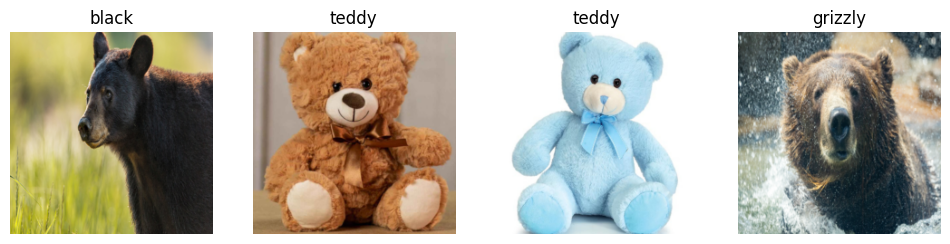

In [4]:
# Configuration de la structure de données (DataBlock) pour le Deep Learning
bears = DataBlock(
    # Définition des types d'entrée/sortie : ImageBlock (images) et CategoryBlock (étiquettes textuelles)
    blocks=(ImageBlock, CategoryBlock),
    # Fonction pour lister tous les fichiers d'images de manière récursive
    get_items=get_image_files,
    # Séparation automatique : 20% des données pour la validation (test) et 80% pour l'entraînement
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    # La classe de chaque image est déterminée par le nom de son dossier parent (ex: grizzly)
    get_y=parent_label,
    # Transformation individuelle : redimensionnement et rognage aléatoire à 224x224 pixels
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    # Augmentation de données sur chaque lot (rotation, luminosité, etc.) pour éviter le surapprentissage
    batch_tfms=aug_transforms())

# Création des chargeurs de données (DataLoaders) à partir du chemin contenant nos images
dls = bears.dataloaders(path)
# Affichage d'un lot d'images de validation pour vérifier la conformité du pipeline
dls.valid.show_batch(max_n=4, nrows=1)

## 3. Entraînement et nettoyage des données à l'aide du modèle
Nous créons un modèle d'apprentissage par transfert basé sur l'architecture standard ResNet-18, puis nous affinons le modèle (`fine_tune`) sur nos données.
Ensuite, nous analysons les erreurs à l'aide d'une matrice de confusion et de la visualisation des pires pertes (`top losses`). Enfin, nous utilisons l'outil interactif `ImageClassifierCleaner` fourni par fastai pour identifier et corriger manuellement les erreurs de labellisation ou les images hors-sujet.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 235MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,nan,5.090632,0.785714,00:06


/usr/local/lib/python3.13/dist-packages/fastprogress/fastprogress.py:93: UserWarning: Your generator is empty.
  warn("Your generator is empty.")


epoch,train_loss,valid_loss,error_rate,time
0,nan,5.090632,0.785714,00:05
1,nan,5.090632,0.785714,00:05
2,nan,5.090632,0.785714,00:05
3,nan,5.090632,0.785714,00:05


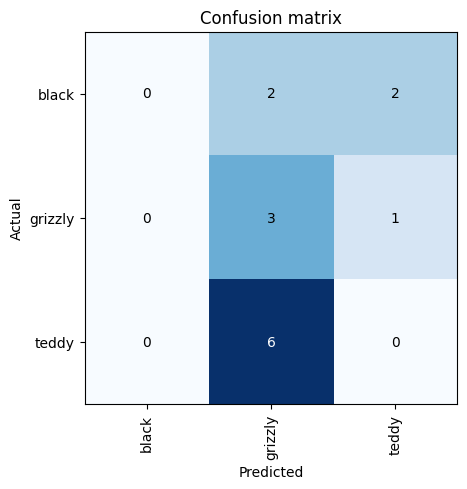

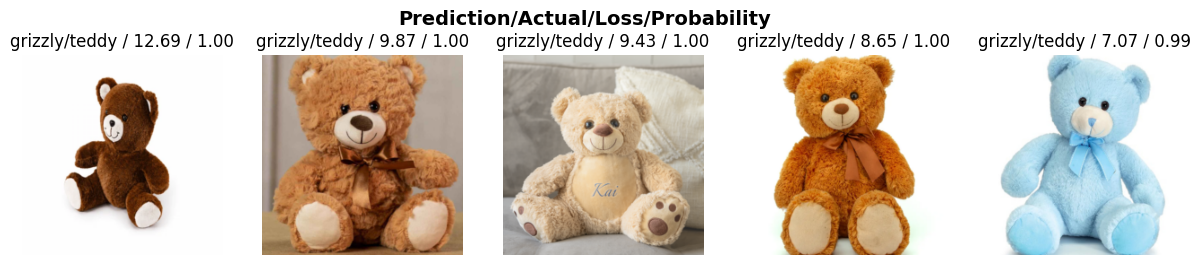

In [5]:
# Création du modèle basé sur l'architecture ResNet-18 (apprentissage par transfert)
# Nous utilisons 'error_rate' (taux d'erreur) comme métrique de suivi
learn = vision_learner(dls, resnet18, metrics=error_rate)

# Entraînement du modèle avec la méthode d'ajustement fin ('fine_tune') sur 4 époques
# Cette méthode gèle d'abord les premières couches puis les ajuste progressivement
learn.fine_tune(4)

# Interprétation des résultats de l'entraînement
interp = ClassificationInterpretation.from_learner(learn)
# Visualisation de la matrice de confusion pour analyser les erreurs de classification
interp.plot_confusion_matrix()
# Visualisation des images sur lesquelles le modèle a commis les plus grosses erreurs de prédiction
interp.plot_top_losses(5, nrows=1)

In [6]:
# Initialisation de l'outil interactif de nettoyage de données de fastai
# Cet outil permet de repérer facilement les mauvaises images directement depuis l'interface
cleaner = ImageClassifierCleaner(learn)
cleaner

In [7]:
# Application effective des décisions de nettoyage prises via l'interface interactive
# 1. Suppression physique des images marquées pour suppression
for idx in cleaner.delete():
    cleaner.fns[idx].unlink()

# 2. Déplacement des images reclassifiées vers leur dossier de destination correct
for idx, cat in cleaner.change():
    shutil.move(str(cleaner.fns[idx]), path/cat)

# Conseil : Une fois nettoyé, il est recommandé de relancer l'entraînement (sections 2 et 3)

## 4. Exportation du modèle
La méthode `export` sauvegarde l'architecture du réseau, les poids optimisés ainsi que l'ensemble des transformations définies dans le pipeline de validation des `DataLoaders` (garantissant qu'aucune augmentation de données aléatoire n'est appliquée lors de l'inférence). Nous enregistrons également un fichier de métadonnées au format JSON pour le suivi de version.

In [8]:
# Exportation complète du modèle entraîné sous forme de fichier sérialisé .pkl
learn.export('export.pkl')

# Création de métadonnées pour documenter la version du modèle, le vocabulaire et les performances
meta = {
    "vocab": list(dls.vocab),
    "error_rate": float(learn.validate()[1]), # Évaluation du taux d'erreur final sur l'ensemble de validation
    "fastai": __import__('fastai').__version__,
    "trained": time.strftime('%Y-%m-%d')
}

# Sauvegarde de ces métadonnées au format JSON pour garantir la traçabilité en production
json.dump(meta, open('model_meta.json', 'w'), indent=2)
meta

{'vocab': ['black', 'grizzly', 'teddy'],
 'error_rate': 0.7857142686843872,
 'fastai': '2.8.12',
 'trained': '2026-10-01'}

## 5. Inférence et vérifications de sécurité
Le livre met en garde contre les données aberrantes ou hors-domaine. Pour sécuriser notre système en production, nous mettons en place un garde-fou simple : si la confiance (probabilité) de la classe prédite est inférieure à un seuil défini (ici 80 %), nous classons l'image comme « incertaine » et la renvoyons vers une validation humaine.

In [9]:
# Chargement du modèle exporté en mode CPU (recommandé pour la production et l'inférence simple)
learn_inf = load_learner('export.pkl', cpu=True)

# Définition d'un seuil de confiance minimum de 80 % pour sécuriser les décisions
THRESH = 0.80

# Fonction d'inférence sécurisée
def classify(img):
    pred, idx, probs = learn_inf.predict(img)
    conf = float(probs[idx])
    # Si le score de confiance est inférieur au seuil, la prédiction est classée comme incertaine
    return {
        'label': str(pred) if conf >= THRESH else 'uncertain',
        'confidence': round(conf, 4),
        'probs': {c: round(float(p), 4) for c, p in zip(learn_inf.dls.vocab, probs)}
    }

# Test de la fonction sur un échantillon local d'ours grizzly
sample = get_image_files(path/'grizzly')[0]
classify(PILImage.create(sample))

/usr/local/lib/python3.13/dist-packages/fastai/learner.py:456: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


{'label': 'grizzly',
 'confidence': 0.99,
 'probs': {'black': 0.0011, 'grizzly': 0.99, 'teddy': 0.0089}}

In [10]:
# Smoke test: checks classification without crashing if accuracy is not yet perfect
def test_model():
    print("Running model smoke tests...")
    for c in learn_inf.dls.vocab:
        f = get_image_files(path/c)[0]
        res = classify(PILImage.create(f))
        pred_label = res['label']
        if pred_label in (c, 'uncertain'):
            print(f"✓ Category '{c}': Correctly classified or uncertain (Got: '{pred_label}')")
        else:
            print(f"⚠ Category '{c}': Model predicted '{pred_label}' (Expected: '{c}'). Model might need more training data or fine-tuning.")

test_model()

Running model smoke tests...


⚠ Category 'black': Model predicted 'grizzly' (Expected: 'black'). Model might need more training data or fine-tuning.


✓ Category 'grizzly': Correctly classified or uncertain (Got: 'grizzly')


⚠ Category 'teddy': Model predicted 'grizzly' (Expected: 'teddy'). Model might need more training data or fine-tuning.


## 6a. Application dans le Notebook (Approche du livre : ipywidgets + Voilà)
Cette section montre comment concevoir rapidement une interface utilisateur interactive directement au sein de Jupyter à l'aide de composants graphiques (`ipywidgets`).

In [11]:
import ipywidgets as widgets
from ipywidgets import VBox

# Initialisation des composants graphiques interactifs pour l'interface de test rapide dans le notebook
btn_upload = widgets.FileUpload() # Bouton de chargement d'image
out_pl = widgets.Output()          # Zone d'affichage de l'image
lbl_pred = widgets.Label()         # Libellé pour afficher le résultat
btn_run = widgets.Button(description='Classifier')

# Callback déclenché lors du clic sur le bouton
def on_click(change):
    # Lecture de la dernière image chargée par l'utilisateur
    img = PILImage.create(btn_upload.data[-1])
    out_pl.clear_output()
    with out_pl:
        display(img.to_thumb(128,128))
    # Exécution de l'inférence
    r = classify(img)
    lbl_pred.value = f"Résultat : {r['label']} (Confiance : {r['confidence']:.2%})"

btn_run.on_click(on_click)

# Assemblage vertical de l'interface graphique
VBox([widgets.Label('Sélectionnez l\'image d\'un ours !'), btn_upload, btn_run, out_pl, lbl_pred])

Pour lancer cette interface sous forme d'application web autonome, vous pouvez installer et utiliser Voilà en exécutant :
`voila bear_app.ipynb` (nécessite l'installation préalable de `voila`).

## 6b. API de Production Réelle (FastAPI) — Écrite dans le dossier `app/`
Pour un déploiement robuste et scalable, nous créons une API Web moderne avec FastAPI. Cette API comprend :
* Une route de diagnostic santé (`/health`) qui renvoie les métadonnées et la version du modèle.
* Une route de prédiction (`/predict`) acceptant l'envoi d'images par formulaire HTTP POST, avec gestion des erreurs de format et limitation de la taille du fichier.

In [12]:
os.makedirs('app', exist_ok=True)
shutil.copy('export.pkl','app/export.pkl'); shutil.copy('model_meta.json','app/model_meta.json')
open('app/main.py','w').write('''
import io, json, logging, time
from fastapi import FastAPI, File, UploadFile, HTTPException
from fastai.vision.all import load_learner, PILImage

log = logging.getLogger("bear-api")
app = FastAPI(title="Bear classifier")
learn = load_learner("export.pkl", cpu=True)
META = json.load(open("model_meta.json"))
THRESH = 0.80

@app.get("/health")
def health(): return {"status": "ok", **META}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    data = await file.read()
    if len(data) > 5_000_000: raise HTTPException(413, "Image too large")
    try: img = PILImage.create(io.BytesIO(data))
    except Exception: raise HTTPException(400, "Not a valid image")
    t = time.time()
    pred, idx, probs = learn.predict(img)
    conf = float(probs[idx])
    log.info("pred=%s conf=%.3f ms=%.0f", pred, conf, (time.time()-t)*1000)
    return {"label": str(pred) if conf >= THRESH else "uncertain",
            "confidence": conf,
            "probs": dict(zip(map(str, learn.dls.vocab), map(float, probs)))}
''')
open('app/requirements.txt','w').write('fastai\nfastapi\nuvicorn\npython-multipart\n')
open('app/Dockerfile','w').write('''FROM python:3.11-slim
WORKDIR /app
RUN pip install --no-cache-dir torch torchvision --index-url https://download.pytorch.org/whl/cpu
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY . .
EXPOSE 8000
CMD ["uvicorn","main:app","--host","0.0.0.0","--port","8000"]
''')
os.listdir('app')

['Dockerfile', 'main.py', 'model_meta.json', 'export.pkl', 'requirements.txt']

Pour tester et exécuter l'API localement :
```bash
cd app && uvicorn main:app --port 8000
curl -F file=@grizzly.jpg localhost:8000/predict
# Ou avec Docker :
docker build -t bear-api . && docker run -p 8000:8000 bear-api
```

## 6c. Démo rapide avec Gradio (Optionnel, idéal pour Hugging Face Spaces)
Gradio permet de générer instantanément une interface web de test très élégante et facilement partageable.

In [16]:
import gradio as gr

# Définition de la fonction d'interface compatible avec Gradio
def _fn(img):
    # Retourne les probabilités pour chacune des classes sous forme de dictionnaire
    return classify(PILImage.create(img))['probs']

# Configuration de l'interface Gradio :
# - Entrée : Sélecteur d'image avec chemin d'accès temporaire
# - Sortie : Affichage des classes les plus probables
demo = gr.Interface(_fn, gr.Image(type='filepath'), gr.Label(num_top_classes=3))

# Pour lancer l'application en local ou générer un lien public, décommentez la ligne suivante :
demo.launch(
    share=True,
    mcp_server=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cc08750dd58a7b8919.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 7. Liste de contrôle pour la mise en production (Checklist)
- **Données hors-domaine :** Enregistrer systématiquement les prédictions et les indices de confiance en production pour analyser chaque semaine les cas incertains.
- **Humain dans la boucle :** Renvoyer les cas marqués comme `incertain` vers une validation manuelle plutôt que de prendre une décision automatique erronée.
- **Déploiement progressif :** Utiliser un mode fantôme (shadow mode), puis déployer sur un faible pourcentage du trafic avant d'ouvrir pleinement l'accès.
- **Boucle de rétroaction :** Sauvegarder les images vérifiées manuellement, corriger les étiquettes avec `ImageClassifierCleaner`, ré-entraîner régulièrement le modèle et mettre à jour le fichier `model_meta.json`.
- **Biais :** S'assurer que les données d'entraînement sont représentatives de l'usage réel sur le terrain.
- **Dérive du modèle (Drift) :** Surveiller l'évolution de la distribution de confiance des prédictions réelles par rapport aux données de validation d'origine.
- **Opérations :** Privilégier une inférence sur processeur (CPU) pour réduire les coûts, figer les versions de fastai/torch, monitorer la route `/health` et intégrer des tests automatisés d'intégration.